# Charting Boulder: Population growth - Rebuttal

[Brian C. Keegan, Ph.D.](http://www.brianckeegan.com)  
July 2025

Released under a [MIT License](https://opensource.org/licenses/MIT).

## Load libraries

In [1]:
import pandas as pd
import numpy as np

pd.options.display.max_columns = 100

%matplotlib inline
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors

import json, requests

## Load data

### LODES jobs data

Load the "Workplace Area Characteristics" (WAC) data from [LODES](https://lehd.ces.census.gov/), the U.S. Census Bureau's Longitudinal Employer-Household Dynamics jobs database.

In [2]:
wac_city_df = pd.read_csv('wac-boulder.csv')

wac_city_df.head()

,w_geocode,segment,year,C000
0,80130137042000,S000,2002,4
1,80130137042010,S000,2002,18
2,80130137043020,S000,2002,14
3,80130137044011,S000,2002,1
4,80130137044029,S000,2002,46


### Boulder housing units

Load [housing data](https://demography.dola.colorado.gov/assets/html/housing.html) from the Colorado State Demography Office.

In [3]:
muni_pop_housing_df = pd.read_excel('muni-pop-housing.xlsx',header=1)

# Filter SDO housing data to City of Boulder
c0 = muni_pop_housing_df['PLACE'] == 'Boulder'
pop_housing_boulder_df = muni_pop_housing_df[c0]

pop_housing_boulder_df.head()

,YEAR,COUNTY,PLACE,CFIPS,PFIPS,Total Population,Household Population,Group Quarters Population,Household Size,Total Housing Units,Occupied Housing Units,Vacant Housing Units,Vacancy Percent,Household Population to Total Housing Units Ratio
27,2010,Boulder County,Boulder,13,7850,97901,89349,8552,2.16,43497,41365.0,2132.0,4.90,2.054142
384,2011,Boulder County,Boulder,13,7850,100233,91034,9199,2.16,43908,42089.0,1819.0,4.14,2.073290
741,2012,Boulder County,Boulder,13,7850,101701,91797,9904,2.16,43863,42403.0,1460.0,3.33,2.092812
1098,2013,Boulder County,Boulder,13,7850,103443,92863,10580,2.17,44144,42854.0,1290.0,2.92,2.103638
1455,2014,Boulder County,Boulder,13,7850,105583,94326,11257,2.17,44869,43476.0,1393.0,3.10,2.102253


### CU Boulder enrollment

Load [historical CU enrollment data](https://data.colorado.edu/reports/enrollment-cu-boulder-1877) from the Colorado Open Data Portal.

In [4]:
cu_enrollments_df = pd.read_csv('cu-enrollments.csv',sep='\t')
cu_enrollments_df.tail()

,Year as Date,Highlight Dot,Annotation Button,Term,Year,All Students,Female,Graduate,Male,Nonresident,Resident,Total,Total Female Students,Total Graduate Students,Total Male Students,Total Nonresidents,Total Residents,Total Undergraduate Students,Undergraduate
144,2021,False,Hide Annotations,Spring,2021,NaN,14946.0,5861.0,17831.0,13135.0,19642.0,32777.0,NaN,5861.0,NaN,NaN,NaN,26916.0,26916.0
145,2022,False,Hide Annotations,Spring,2022,NaN,14856.0,6091.0,18301.0,14061.0,19096.0,33157.0,NaN,6091.0,NaN,NaN,NaN,27066.0,27066.0
146,2023,False,Hide Annotations,Spring,2023,NaN,15336.0,6264.0,18487.0,14410.0,19413.0,33823.0,NaN,6264.0,NaN,NaN,NaN,27559.0,27559.0
147,2024,False,Hide Annotations,Spring,2024,NaN,15958.0,6158.0,18800.0,14678.0,20080.0,34758.0,NaN,6158.0,NaN,NaN,NaN,28600.0,28600.0
148,2025,True,Hide Annotations,Spring,2025,NaN,16563.0,6219.0,19204.0,14940.0,20827.0,35767.0,NaN,6219.0,NaN,NaN,NaN,29548.0,29548.0


### Annual county and municipal estimates

Load SDO [annual population estimate data](https://demography.dola.colorado.gov/assets/html/population.html) for counties and municipalities from 1980 to present.

In [5]:
county_muni_df = pd.read_csv('county-muni-timeseries.csv')

# Clean
county_muni_df['municipalityname'] = county_muni_df['municipalityname'].str.strip()

# Filter to Boulder County and city of Boulder
city_pop_s = county_muni_df.loc[county_muni_df['municipalityname'] == 'Boulder',['year','totalpopulation']].set_index('year')['totalpopulation']

# Inspect
city_pop_s.tail()

year
2019    108496.0
2020    108965.0
2021    104704.0
2022    107037.0
2023    106852.0
Name: totalpopulation, dtype: float64

### Historical NHGIS estimates

Load historical estimates of populations for places and counties from [IPUMS NHGIS](https://www.nhgis.org/).

In [6]:
nhgis_county_df = pd.read_csv('nhgis-ts-county.csv',dtype={'STATEFP':str,'STATENH':str,'COUNTYFP':str,'COUNTYNH':str})

nhgis_place_df = pd.read_csv('nhgis-ts-place.csv',dtype={'STATEFP':str,'STATENH':str,'PLACEA':str})

nhgis_place_df.head()

,NHGISCODE,GJOIN1970,GJOIN1980,GJOIN1990,GJOIN2000,GJOIN2010,GJOIN2020,STATE,STATEFP,STATENH,PLACE,PLACEA,NAME1970,NAME1980,NAME1990,NAME2000,NAME2010,NAME2020,AV0AA1970,AV0AA1980,AV0AA1990,AV0AA2000,AV0AA2010,AV0AA2020
0,G01000100,NaN,NaN,NaN,NaN,G01000100,G01000100,Alabama,01,010,Abanda CDP,00100,NaN,NaN,NaN,NaN,Abanda CDP,Abanda CDP,NaN,NaN,NaN,NaN,192.0,133.0
1,G01000124,G0100005,G0100005,G01000124,G01000124,G01000124,G01000124,Alabama,01,010,Abbeville city,00124,Abbeville,ABBEVILLE CITY,Abbeville city,Abbeville city,Abbeville city,Abbeville city,2996.0,3155.0,3173.0,2987.0,2688.0,2358.0
2,G01000460,G0100010,G0100010,G01000460,G01000460,G01000460,G01000460,Alabama,01,010,Adamsville city,00460,Adamsville,ADAMSVILLE CITY,Adamsville city,Adamsville city,Adamsville city,Adamsville city,2412.0,2498.0,4161.0,4965.0,4522.0,4366.0
3,G01000484,G0100015,G0100015,G01000484,G01000484,G01000484,G01000484,Alabama,01,010,Addison town,00484,Addison,ADDISON TOWN,Addison town,Addison town,Addison town,Addison town,NaN,746.0,626.0,723.0,758.0,659.0
4,G01000676,G0100020,G0100020,G01000676,G01000676,G01000676,G01000676,Alabama,01,010,Akron town,00676,Akron,AKRON TOWN,Akron town,Akron town,Akron town,Akron town,NaN,604.0,468.0,521.0,356.0,225.0


### Similar cities catalog

Load a curated list of cities similar to Boulder for sister-city comparison.

In [7]:
with open('similar-boulder.json','r') as f:
    similar_cities = json.load(f)

print(len(similar_cities))

similar_cities[:3]

26


[{'city': 'Boulder',
  'state': 'Colorado',
  'place_fips': '0807850',
  'county': 'Boulder County',
  'county_fips': '08013',
  'msa': 'Boulder, CO MSA'},
 {'city': 'Ann Arbor',
  'state': 'Michigan',
  'place_fips': '2603000',
  'county': 'Washtenaw County',
  'county_fips': '26161',
  'msa': 'Ann Arbor, MI MSA'},
 {'city': 'Cambridge',
  'state': 'Massachusetts',
  'place_fips': '2511000',
  'county': 'Middlesex County',
  'county_fips': '25017',
  'msa': 'Boston–Cambridge–Newton, MA–NH MSA'}]

### Integrity check

Verify the six input datasets loaded with expected shape and that the similar-cities catalog contains the expected number of entries.

In [8]:
assert len(similar_cities) > 20, f'Expected at least 20 similar cities; got {len(similar_cities)}'
assert not wac_city_df.empty and 'year' in wac_city_df.columns, 'WAC data missing or malformed'
assert not muni_pop_housing_df.empty, 'Housing data empty'
assert not cu_enrollments_df.empty and 'Total' in cu_enrollments_df.columns, 'CU enrollments missing Total column'
assert not nhgis_county_df.empty and not nhgis_place_df.empty, 'NHGIS county or place data empty'
print(f'✓ Similar cities:      {len(similar_cities)}')
print(f'✓ WAC rows:            {len(wac_city_df):,}')
print(f'✓ Housing rows:        {len(muni_pop_housing_df):,}')
print(f'✓ CU enrollment rows:  {len(cu_enrollments_df):,}')
print(f'✓ NHGIS county rows:   {len(nhgis_county_df):,}')
print(f'✓ NHGIS place rows:    {len(nhgis_place_df):,}')

✓ Similar cities:      26
✓ WAC rows:            18,471
✓ Housing rows:        4,998
✓ CU enrollment rows:  149
✓ NHGIS county rows:   3,248
✓ NHGIS place rows:    34,095


## Data preparation and cleaning

Filter NHGIS data to `similar_d` entries.

In [9]:
nhgis_place_fips_l = []
for city in similar_cities:
    state = city['place_fips'][:2]
    place = city['place_fips'][2:]
    nhgis_place_fips_l.append('G{}{:06d}'.format(state, int(place)))

nhgis_similar_place_df = nhgis_place_df.loc[nhgis_place_df['NHGISCODE'].isin(nhgis_place_fips_l),:]

# Manually enter missing Irvine population
nhgis_similar_place_df.loc[2924,'AV0AA1970'] = 7381	

# Put the selection into similar-boulder.json order. `.isin()` keeps each source file's own
# row order, which is not the same for places and counties, so the two must be aligned
# explicitly before any positional comparison below.
nhgis_similar_place_df = (nhgis_similar_place_df.set_index('NHGISCODE')
                          .loc[nhgis_place_fips_l]
                          .reset_index())

print(len(nhgis_similar_place_df))

nhgis_similar_place_df.head()

26


,NHGISCODE,GJOIN1970,GJOIN1980,GJOIN1990,GJOIN2000,GJOIN2010,GJOIN2020,STATE,STATEFP,STATENH,PLACE,PLACEA,NAME1970,NAME1980,NAME1990,NAME2000,NAME2010,NAME2020,AV0AA1970,AV0AA1980,AV0AA1990,AV0AA2000,AV0AA2010,AV0AA2020
0,G08007850,G0800110,G0800110,G08007850,G08007850,G08007850,G08007850,Colorado,08,080,Boulder city,07850,Boulder,BOULDER CITY,Boulder city,Boulder city,Boulder city,Boulder city,66870.0,76685.0,83312.0,94673.0,97385.0,108250.0
1,G26003000,G2600080,G2600080,G26003000,G26003000,G26003000,G26003000,Michigan,26,260,Ann Arbor city,03000,Ann Arbor,ANN ARBOR CITY,Ann Arbor city,Ann Arbor city,Ann Arbor city,Ann Arbor city,99797.0,107966.0,109592.0,114024.0,113934.0,123851.0
2,G25011000,G2500610,G2500610,G25011000,G25011000,G25011000,G25011000,Massachusetts,25,250,Cambridge city,11000,Cambridge,CAMBRIDGE CITY,Cambridge city,Cambridge city,Cambridge city,Cambridge city,100361.0,95322.0,95802.0,101355.0,105162.0,118403.0
3,G06006000,G0600245,G0600245,G06006000,G06006000,G06006000,G06006000,California,06,060,Berkeley city,06000,Berkeley,BERKELEY CITY,Berkeley city,Berkeley city,Berkeley city,Berkeley city,116716.0,103328.0,102724.0,102743.0,112580.0,124321.0
4,G55048000,G5501475,G5501475,G55048000,G55048000,G55048000,G55048000,Wisconsin,55,550,Madison city,48000,Madison,MADISON CITY,Madison city,Madison city,Madison city,Madison city,173258.0,170616.0,191262.0,208054.0,233209.0,269840.0


Names of places.

In [10]:
print(nhgis_similar_place_df['NAME2020'].str.replace(' city','').values,'\n\n',len(nhgis_similar_place_df))

<StringArray>
[         'Boulder',        'Ann Arbor',        'Cambridge',
         'Berkeley',          'Madison',           'Durham',
         'Pasadena',    'Santa Barbara',    'Mountain View',
      'Bloomington',     'Fort Collins',            'Tempe',
         'Evanston',            'Provo',  'College Station',
       'Huntsville',      'Gainesville',           'Eugene',
        'Rochester',           'Irvine',        'Iowa City',
         'Syracuse',       'Pittsburgh', 'Chapel Hill town',
        'New Haven',      'Baton Rouge']
Length: 26, dtype: str 

 26


Counties.

In [11]:
nhgis_county_fips_l = []
for city in similar_cities:
    state = city['county_fips'][:2]
    county = city['county_fips'][2:]
    nhgis_county_fips_l.append('G{}{:04d}0'.format(state, int(county)))

nhgis_similar_county_df = nhgis_county_df.loc[nhgis_county_df['GISJOIN'].isin(nhgis_county_fips_l),:]

# Same ordering fix as the places above, so row i is the same city in both frames
nhgis_similar_county_df = (nhgis_similar_county_df.set_index('GISJOIN')
                           .loc[nhgis_county_fips_l]
                           .reset_index())

print(len(nhgis_similar_county_df))

nhgis_similar_county_df.head()

26


,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,AV0AA1970,AV0AA1980,AV0AA1990,AV0AA2000,AV0AA2010,AV0AA2020
0,G0800130,Colorado,08,080,Boulder County,013,0130,131889.0,189625.0,225339.0,291288.0,294567.0,330758.0
1,G2601610,Michigan,26,260,Washtenaw County,161,1610,234103.0,264748.0,282937.0,322895.0,344791.0,372258.0
2,G2500170,Massachusetts,25,250,Middlesex County,017,0170,1397268.0,1367034.0,1398468.0,1465396.0,1503085.0,1632002.0
3,G0600010,California,06,060,Alameda County,001,0010,1073184.0,1105379.0,1279182.0,1443741.0,1510271.0,1682353.0
4,G5500250,Wisconsin,55,550,Dane County,025,0250,290272.0,323545.0,367085.0,426526.0,488073.0,561504.0


Create a list of place names and columns to use later.

In [12]:
place_names = nhgis_similar_place_df.loc[:,'PLACE'].str.replace(' city','').str.replace(' CDP','').str.replace(' town','').values

nhgis_name_cols = ['AV0AA1970','AV0AA1980','AV0AA1990','AV0AA2000','AV0AA2010','AV0AA2020']

## Plot jobs-housing ratio

<Axes: xlabel='year'>

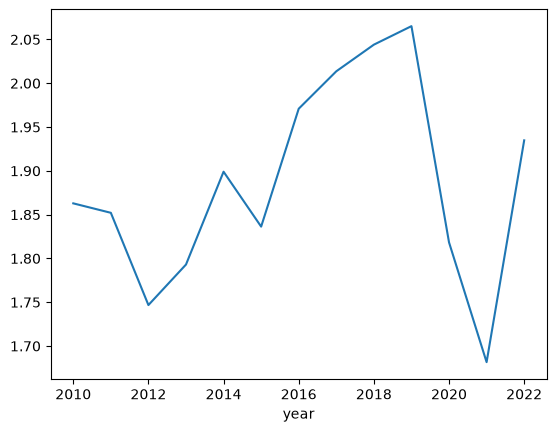

In [13]:
# Extract total housing units and year
boulder_housing_s = pop_housing_boulder_df.set_index('YEAR')['Total Housing Units']

# Use WAC data to compute annual jobs within City of Boulder
wac_boulder_s = wac_city_df.groupby('year')['C000'].sum()

# Compute jobs/housing ratio
jobs_housing_ratio = wac_boulder_s / boulder_housing_s

# Export jobs-housing ratio for Datawrapper
jobs_housing_ratio.to_csv('jobs_housing_ratio_for_datawrapper.csv', header=['ratio'])

jobs_housing_ratio.plot()

## Plot CU student fraction

(0.2, 0.35)

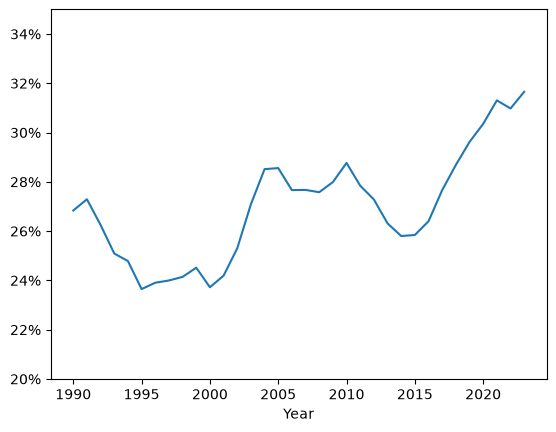

In [14]:
cu_total_enrollments = cu_enrollments_df.set_index('Year')['Total'].dropna()

# Student fraction of City of Boulder population
total_fraction = cu_total_enrollments / city_pop_s

# Export CU student-fraction series for Datawrapper
total_fraction.to_csv('cu_student_fraction_for_datawrapper.csv', header=['fraction'])

f, ax = plt.subplots()
total_fraction.loc[1990:].plot(ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, 0))
ax.set_ylim((.2, .35))

## Plot sister cities growth

In [15]:
place_pops_norm = nhgis_similar_place_df.loc[:,nhgis_name_cols].div(nhgis_similar_place_df.loc[:,'AV0AA1970'],axis=0).T
place_pops_norm.index = [1970,1980,1990,2000,2010,2020]

county_pops_norm = nhgis_similar_county_df.loc[:,nhgis_name_cols].div(nhgis_similar_county_df.loc[:,'AV0AA1970'],axis=0).T
county_pops_norm.index = [1970,1980,1990,2000,2010,2020]

<Axes: >

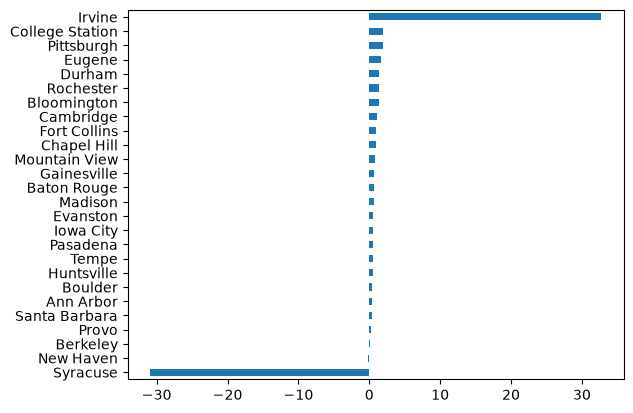

In [16]:
delta_place = (nhgis_similar_place_df['AV0AA2020'] - nhgis_similar_place_df['AV0AA1970'])/nhgis_similar_place_df['AV0AA1970']
delta_place.index = place_names

delta_county = (nhgis_similar_county_df['AV0AA2020'] - nhgis_similar_county_df['AV0AA1970'])/nhgis_similar_county_df['AV0AA1970']
delta_county.index = place_names

delta_ratio = delta_place/delta_county
delta_ratio.sort_values().plot.barh()

<Axes: >

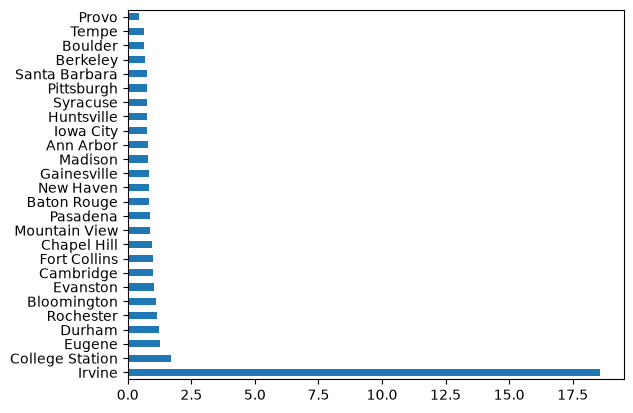

In [17]:
place_pops_norm.columns = place_names
county_pops_norm.columns = place_names

place_pct_county = place_pops_norm.div(county_pops_norm, axis=0)

delta_place_delta_county = place_pct_county.loc[2020, :].sort_values(ascending=False)

# Export place-vs-county growth ratio for Datawrapper
delta_place_delta_county.to_csv('sister_cities_place_county_ratio.csv', header=['ratio'])

delta_place_delta_county.plot.barh()

## Pinned headline numbers

Figures the rebuttal column references, recomputed from variables defined earlier.

In [18]:
# Jobs-housing ratio
jh_latest_year = int(jobs_housing_ratio.dropna().index.max())
jh_latest = float(jobs_housing_ratio.dropna().iloc[-1])
jh_earliest_year = int(jobs_housing_ratio.dropna().index.min())
jh_earliest = float(jobs_housing_ratio.dropna().iloc[0])

# CU student fraction of city population
cu_fraction_latest_year = int(total_fraction.dropna().index.max())
cu_fraction_latest = float(total_fraction.dropna().iloc[-1])
cu_fraction_peak = float(total_fraction.dropna().max())
cu_fraction_peak_year = int(total_fraction.dropna().idxmax())

# Boulder's growth among the sister-cities cohort
boulder_idx = list(place_names).index('Boulder') if 'Boulder' in place_names else None
n_faster_cities = int((delta_place > delta_place.loc['Boulder']).sum()) if 'Boulder' in delta_place.index else None

print(f'Jobs-housing ratio, {jh_earliest_year}:  {jh_earliest:.2f}')
print(f'Jobs-housing ratio, {jh_latest_year}:    {jh_latest:.2f}')
print(f'CU students as % of city population, {cu_fraction_latest_year}:  {cu_fraction_latest:.1%}')
print(f'Peak CU student share ({cu_fraction_peak_year}):                {cu_fraction_peak:.1%}')
if n_faster_cities is not None:
    print(f'Sister cities growing faster than Boulder 1970-2020:  {n_faster_cities} of {len(delta_place)}')

Jobs-housing ratio, 2010:  1.86
Jobs-housing ratio, 2022:    1.93
CU students as % of city population, 2023:  31.7%
Peak CU student share (2023):                31.7%
Sister cities growing faster than Boulder 1970-2020:  11 of 26
